## Homework 2

Name: Qian Ling  
GitHub Username: qianling-sketch
USC ID: 7728910687

### 1. Combined Cycle Power Plant Data Set

### (a)

The Combined Cycle Power Plant dataset was downloaded.

### (b)(i)

In [25]:
import pandas as pd

df = pd.read_excel("Folds5x2_pp.xlsx", sheet_name="Sheet1")
df.head()

,AT,V,AP,RH,PE
0,14.96,41.76,1024.07,73.17,463.26
1,25.18,62.96,1020.04,59.08,444.37
2,5.11,39.40,1012.16,92.14,488.56
3,20.86,57.32,1010.24,76.64,446.48
4,10.82,37.50,1009.23,96.62,473.90


In [26]:
df.shape

(9568, 5)

There are 9568 rows and 5 columns in the dataset. Each row represents one hourly observation of the power plant. And columns represent four predictor variables (AT, V, AP, and RH) and one response variable (PE). AT is ambient temperature, V is exhaust vacuum, AP is ambient pressure, RH is relative humidity, and PE is the net hourly electrical energy output.

### (ii)

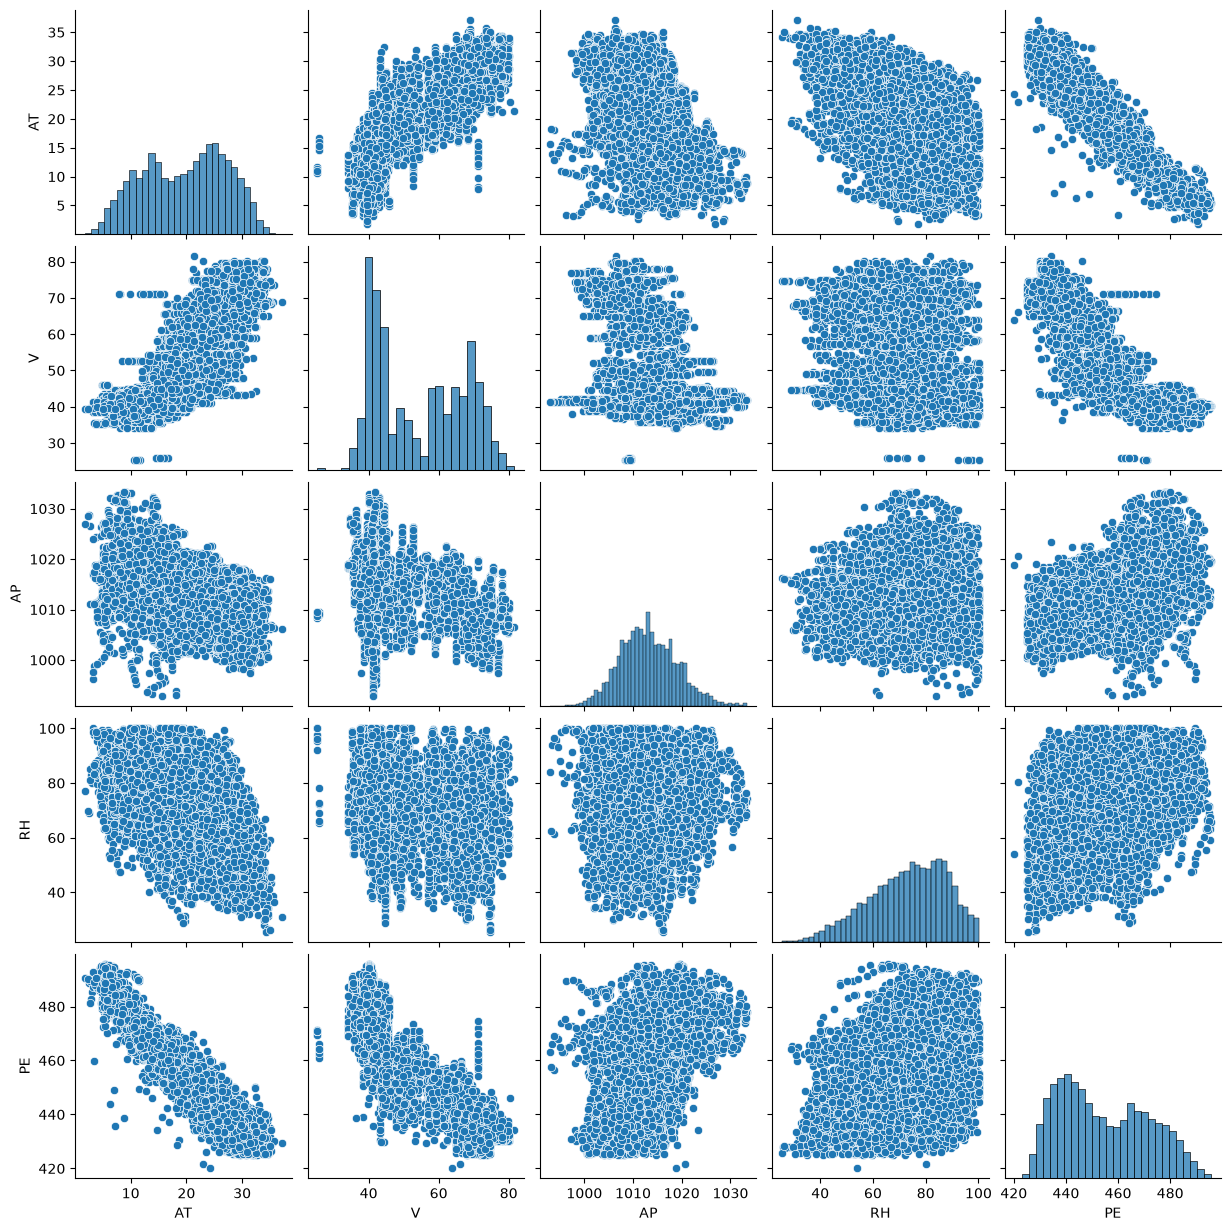

In [27]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.pairplot(df)
plt.show()

Findings: AT and V show a clear negative linear relationship with PE, making them the strongest predictors. AP and RH show weaker, more scattered positive relationships with PE. Among the predictors, AT and V are noticeably correlated with each other, which may indicate multicollinearity. Several variables (AT, V, PE) show bimodal distributions, possibly reflecting seasonal variation in plant operation.

### (iii)

In [28]:
summary = pd.DataFrame({
    "Mean": df.mean(),
    "Median": df.median(),
    "Range": df.max() - df.min(),
    "Q1": df.quantile(0.25),
    "Q3": df.quantile(0.75),
    "IQR": df.quantile(0.75) - df.quantile(0.25)
})

summary

,Mean,Median,Range,Q1,Q3,IQR
AT,19.651231,20.345,35.30,13.5100,25.72,12.2100
V,54.305804,52.080,56.20,41.7400,66.54,24.8000
AP,1013.259078,1012.940,40.41,1009.1000,1017.26,8.1600
RH,73.308978,74.975,74.60,63.3275,84.83,21.5025
PE,454.365009,451.550,75.50,439.7500,468.43,28.6800


### (c)

--- Simple Linear Regression: PE ~ AT ---
                            OLS Regression Results                            
Dep. Variable:                     PE   R-squared:                       0.899
Model:                            OLS   Adj. R-squared:                  0.899
Method:                 Least Squares   F-statistic:                 8.510e+04
Date:                Thu, 24 Sep 2026   Prob (F-statistic):               0.00
Time:                        23:47:50   Log-Likelihood:                -29756.
No. Observations:                9568   AIC:                         5.952e+04
Df Residuals:                    9566   BIC:                         5.953e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const     

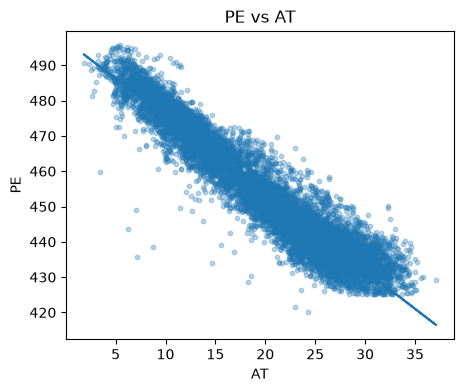

--- Simple Linear Regression: PE ~ V ---
                            OLS Regression Results                            
Dep. Variable:                     PE   R-squared:                       0.757
Model:                            OLS   Adj. R-squared:                  0.756
Method:                 Least Squares   F-statistic:                 2.972e+04
Date:                Thu, 24 Sep 2026   Prob (F-statistic):               0.00
Time:                        23:47:51   Log-Likelihood:                -33963.
No. Observations:                9568   AIC:                         6.793e+04
Df Residuals:                    9566   BIC:                         6.794e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const      

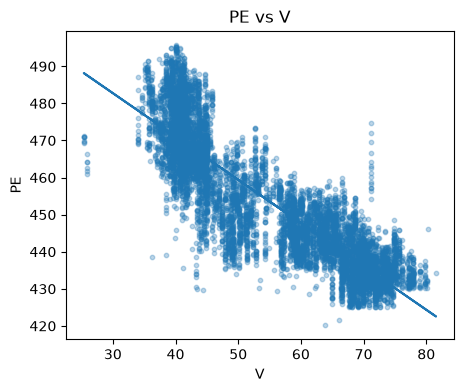

--- Simple Linear Regression: PE ~ AP ---
                            OLS Regression Results                            
Dep. Variable:                     PE   R-squared:                       0.269
Model:                            OLS   Adj. R-squared:                  0.269
Method:                 Least Squares   F-statistic:                     3516.
Date:                Thu, 24 Sep 2026   Prob (F-statistic):               0.00
Time:                        23:47:51   Log-Likelihood:                -39224.
No. Observations:                9568   AIC:                         7.845e+04
Df Residuals:                    9566   BIC:                         7.847e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const     

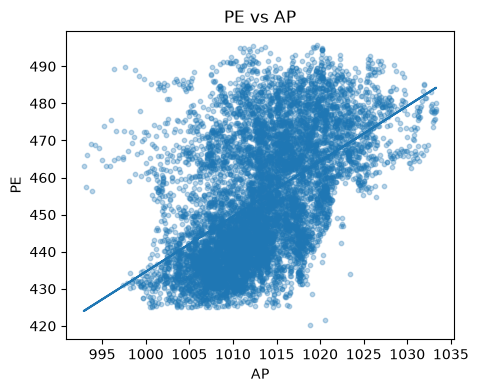

--- Simple Linear Regression: PE ~ RH ---
                            OLS Regression Results                            
Dep. Variable:                     PE   R-squared:                       0.152
Model:                            OLS   Adj. R-squared:                  0.152
Method:                 Least Squares   F-statistic:                     1714.
Date:                Thu, 24 Sep 2026   Prob (F-statistic):               0.00
Time:                        23:47:51   Log-Likelihood:                -39933.
No. Observations:                9568   AIC:                         7.987e+04
Df Residuals:                    9566   BIC:                         7.988e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const     

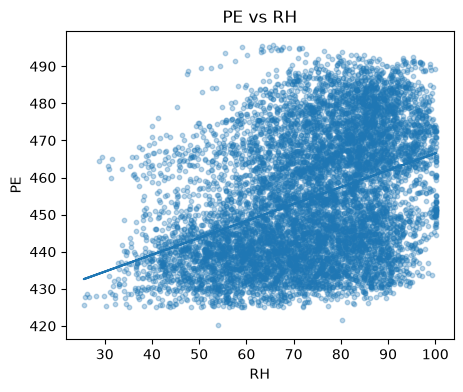

In [29]:
import statsmodels.api as sm
import matplotlib.pyplot as plt

predictors = ['AT', 'V', 'AP', 'RH']

for col in predictors:
    X = sm.add_constant(df[col])
    y = df['PE']
    model = sm.OLS(y, X).fit()

    print(f"--- Simple Linear Regression: PE ~ {col} ---")
    print(model.summary())
    print("\n")

    plt.figure(figsize=(5,4))
    plt.scatter(df[col], df['PE'], alpha=0.3, s=10)
    plt.plot(df[col], model.predict(X))
    plt.xlabel(col)
    plt.ylabel('PE')
    plt.title(f'PE vs {col}')
    plt.show()

All four predictors (AT, V, AP, RH) are statistically significant, because their p-values are all less than 0.001 (< 0.05). 

AT and V have the strongest relationships with PE (R² = 0.899 and 0.757), while AP and RH are much weaker (R² = 0.269 and 0.152). AT and V are negatively related to PE; AP and RH are positively related to PE. 

There are a few points that look far from the main cluster in the scatter plots, but with almost 9,600 data points, they don't have much effect on the regression line, so I did not remove them.

### (d)

In [30]:
X = sm.add_constant(df[predictors])  
y = df['PE']
model_full = sm.OLS(y, X).fit()
print(model_full.summary())

                            OLS Regression Results                            
Dep. Variable:                     PE   R-squared:                       0.929
Model:                            OLS   Adj. R-squared:                  0.929
Method:                 Least Squares   F-statistic:                 3.114e+04
Date:                Thu, 24 Sep 2026   Prob (F-statistic):               0.00
Time:                        23:47:51   Log-Likelihood:                -28088.
No. Observations:                9568   AIC:                         5.619e+04
Df Residuals:                    9563   BIC:                         5.622e+04
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        454.6093      9.749     46.634      0.0

The multiple regression model has an R-squared of 0.929, so the predictors explain about 92.9% of the variation in PE. All four predictors have p-values less than 0.05, so we can reject H0: βj = 0 for AT, V, AP, and RH.

### (e)

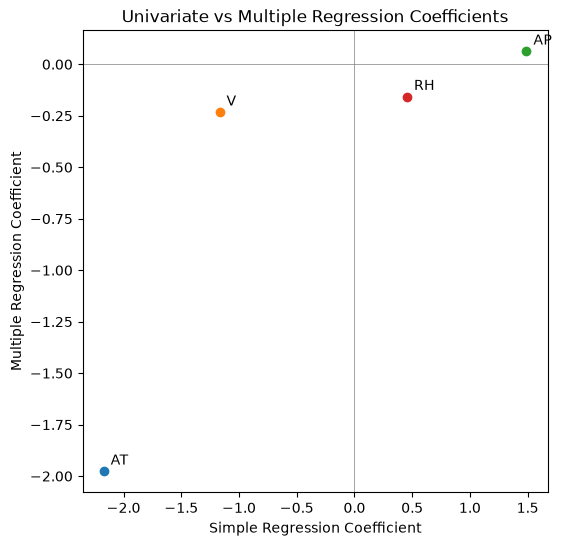

In [31]:
import matplotlib.pyplot as plt

univariate_coefs = {
    'AT': -2.1713,
    'V': -1.1681,
    'AP': 1.4899,
    'RH': 0.4557
}

multiple_coefs = {
    'AT': -1.9775,
    'V': -0.2339,
    'AP': 0.0621,
    'RH': -0.1581
}

plt.figure(figsize=(6,6))
for var in predictors:
    x = univariate_coefs[var]
    y = multiple_coefs[var]
    plt.scatter(x, y)
    plt.annotate(var, (x, y), textcoords="offset points", xytext=(5,5))

plt.xlabel("Simple Regression Coefficient")
plt.ylabel("Multiple Regression Coefficient")
plt.title("Univariate vs Multiple Regression Coefficients")
plt.axhline(0, color='gray', linewidth=0.5)
plt.axvline(0, color='gray', linewidth=0.5)
plt.show()

The coefficients change between the simple and multiple regression models. AT remains strongly negative, while V and AP become much smaller. RH changes from positive to negative.

### (f)

In [32]:
for col in predictors:
    df[f'{col}_2'] = df[col]**2
    df[f'{col}_3'] = df[col]**3
    
    X = sm.add_constant(df[[col, f'{col}_2', f'{col}_3']])
    y = df['PE']
    model_poly = sm.OLS(y, X).fit()
    
    print(f"--- Cubic Regression: PE ~ {col} + {col}^2 + {col}^3 ---")
    print(model_poly.summary())
    print("\n")

--- Cubic Regression: PE ~ AT + AT^2 + AT^3 ---
                            OLS Regression Results                            
Dep. Variable:                     PE   R-squared:                       0.912
Model:                            OLS   Adj. R-squared:                  0.912
Method:                 Least Squares   F-statistic:                 3.299e+04
Date:                Thu, 24 Sep 2026   Prob (F-statistic):               0.00
Time:                        23:47:51   Log-Likelihood:                -29101.
No. Observations:                9568   AIC:                         5.821e+04
Df Residuals:                    9564   BIC:                         5.824e+04
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
cons

There is evidence of nonlinear association for all four predictors. For AT, AP, and RH, the quadratic and cubic terms are statistically significant. For V, the quadratic term is not significant (p = 0.768), but the cubic term is significant (p = 0.014), suggesting some nonlinear association.

### (g)

In [33]:
import statsmodels.formula.api as smf

model_interact = smf.ols(
    'PE ~ AT + V + AP + RH + AT:V + AT:AP + AT:RH + V:AP + V:RH + AP:RH',
    data=df
).fit()

print(model_interact.summary())

                            OLS Regression Results                            
Dep. Variable:                     PE   R-squared:                       0.936
Model:                            OLS   Adj. R-squared:                  0.936
Method:                 Least Squares   F-statistic:                 1.405e+04
Date:                Thu, 24 Sep 2026   Prob (F-statistic):               0.00
Time:                        23:47:51   Log-Likelihood:                -27548.
No. Observations:                9568   AIC:                         5.512e+04
Df Residuals:                    9557   BIC:                         5.520e+04
Df Model:                          10                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept    685.7825     78.640      8.721      0.0

There is evidence of interaction effects. AT:V, AT:RH, V:AP, and AP:RH are statistically significant (p < 0.05). AT:AP and V:RH are not statistically significant.

### (h)

In [34]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
import statsmodels.formula.api as smf

# 1. 70/30 split
train, test = train_test_split(df, test_size=0.3, random_state=1)

# 2. Baseline model: all predictors, no interactions
model1 = smf.ols('PE ~ AT + V + AP + RH', data=train).fit()

train_pred1 = model1.predict(train)
test_pred1 = model1.predict(test)

train_mse1 = mean_squared_error(train['PE'], train_pred1)
test_mse1 = mean_squared_error(test['PE'], test_pred1)

print("Model 1 (baseline)")
print("Train MSE:", train_mse1)
print("Test MSE:", test_mse1)

# 3. Full model with all interactions + quadratic terms
formula_full = 'PE ~ (AT + V + AP + RH)**2 + I(AT**2) + I(V**2) + I(AP**2) + I(RH**2)'
model_full = smf.ols(formula_full, data=train).fit()
print(model_full.summary())

Model 1 (baseline)
Train MSE: 20.766119761450952
Test MSE: 20.77747810688431
                            OLS Regression Results                            
Dep. Variable:                     PE   R-squared:                       0.938
Model:                            OLS   Adj. R-squared:                  0.938
Method:                 Least Squares   F-statistic:                     7181.
Date:                Thu, 24 Sep 2026   Prob (F-statistic):               0.00
Time:                        23:47:51   Log-Likelihood:                -19192.
No. Observations:                6697   AIC:                         3.841e+04
Df Residuals:                    6682   BIC:                         3.852e+04
Df Model:                          14                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------

In [35]:
formula_reduced = 'PE ~ AT + V + AP + RH + AT:V + AT:RH + AP:RH + I(AT**2) + I(AP**2) + I(RH**2)'
model2 = smf.ols(formula_reduced, data=train).fit()
print(model2.summary())

train_pred2 = model2.predict(train)
test_pred2 = model2.predict(test)

train_mse2 = mean_squared_error(train['PE'], train_pred2)
test_mse2 = mean_squared_error(test['PE'], test_pred2)

print("Model 2 (reduced)")
print("Train MSE:", train_mse2)
print("Test MSE:", test_mse2)

                            OLS Regression Results                            
Dep. Variable:                     PE   R-squared:                       0.938
Model:                            OLS   Adj. R-squared:                  0.937
Method:                 Least Squares   F-statistic:                 1.004e+04
Date:                Thu, 24 Sep 2026   Prob (F-statistic):               0.00
Time:                        23:47:51   Log-Likelihood:                -19198.
No. Observations:                6697   AIC:                         3.842e+04
Df Residuals:                    6686   BIC:                         3.849e+04
Df Model:                          10                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept  -1.052e+04   1079.936     -9.738      0.0

### (i)

Best k (raw): 5 Test MSE: 15.704821203761764
Best k (normalized): 4 Test MSE: 14.070606067136888


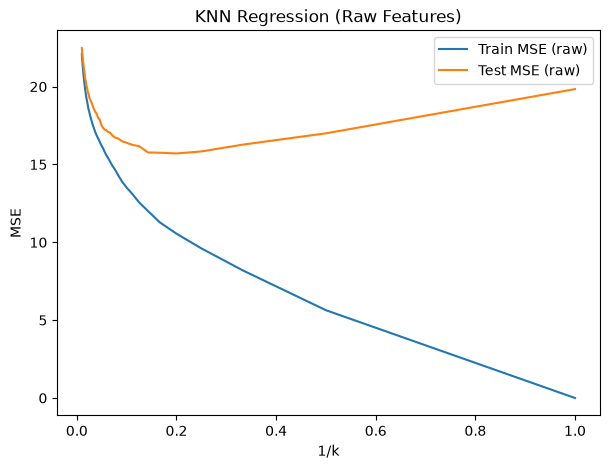

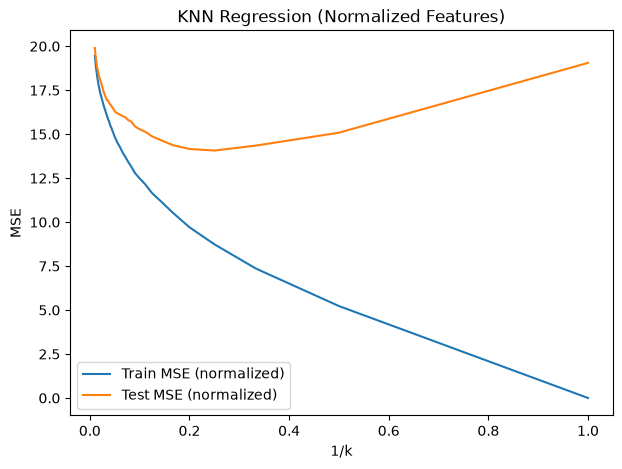

In [36]:
from sklearn.neighbors import KNeighborsRegressor
from sklearn.preprocessing import StandardScaler
import numpy as np
import matplotlib.pyplot as plt

X_train = train[predictors]
X_test = test[predictors]
y_train = train['PE']
y_test = test['PE']

# 1. Raw features
train_mse_raw = []
test_mse_raw = []

for k in range(1, 101):
    knn = KNeighborsRegressor(n_neighbors=k)
    knn.fit(X_train, y_train)
    
    train_pred = knn.predict(X_train)
    test_pred = knn.predict(X_test)
    
    train_mse_raw.append(mean_squared_error(y_train, train_pred))
    test_mse_raw.append(mean_squared_error(y_test, test_pred))

# 2. Normalized features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

train_mse_norm = []
test_mse_norm = []

for k in range(1, 101):
    knn = KNeighborsRegressor(n_neighbors=k)
    knn.fit(X_train_scaled, y_train)
    
    train_pred = knn.predict(X_train_scaled)
    test_pred = knn.predict(X_test_scaled)
    
    train_mse_norm.append(mean_squared_error(y_train, train_pred))
    test_mse_norm.append(mean_squared_error(y_test, test_pred))

# 3. Find best k (lowest test MSE)
best_k_raw = np.argmin(test_mse_raw) + 1
best_k_norm = np.argmin(test_mse_norm) + 1

print("Best k (raw):", best_k_raw, "Test MSE:", min(test_mse_raw))
print("Best k (normalized):", best_k_norm, "Test MSE:", min(test_mse_norm))

# 4. Plot train/test error vs 1/k 
k_values = np.arange(1, 101)
inv_k = 1 / k_values

plt.figure(figsize=(7,5))
plt.plot(inv_k, train_mse_raw, label='Train MSE (raw)')
plt.plot(inv_k, test_mse_raw, label='Test MSE (raw)')
plt.xlabel('1/k')
plt.ylabel('MSE')
plt.title('KNN Regression (Raw Features)')
plt.legend()
plt.show()

plt.figure(figsize=(7,5))
plt.plot(inv_k, train_mse_norm, label='Train MSE (normalized)')
plt.plot(inv_k, test_mse_norm, label='Test MSE (normalized)')
plt.xlabel('1/k')
plt.ylabel('MSE')
plt.title('KNN Regression (Normalized Features)')
plt.legend()
plt.show()

For the raw features, the best k is 5, with a test MSE of 15.70.
For the normalized features, the best k is 4, with a test MSE of 14.07.

### (j)

In [37]:
print("Best Linear Model (Model 2) Test MSE:", test_mse2)
print("Best KNN (normalized, k=4) Test MSE:", min(test_mse_norm))

Best Linear Model (Model 2) Test MSE: 18.263588112319812
Best KNN (normalized, k=4) Test MSE: 14.070606067136888


The normalized KNN model with k=4 gives the lowest test MSE of 14.07. This is lower than the test MSE of the best linear regression model (18.26). The raw KNN model has a test MSE of 15.70, so normalization further improves the KNN performance. Overall, KNN performs better than linear regression on this dataset.
This may be because KNN can capture nonlinear and complex relationships in the data more flexibly than a parametric linear model, even one with interaction and quadratic terms.

## 2

### (a)

Better. When n is large and p is small, there is a lot of data relative to the number of predictors, so a flexible method can fit the true pattern well without overfitting.

### (b)

Worse. When p is large but n is small, a flexible method is more likely to overfit the small amount of data, so an inflexible method would work better.

### (c)

Better. If the relationship is highly non-linear, an inflexible method won't be able to capture the true shape, but a flexible method can adjust to it.

### (d)

Worse. When the variance of the error is very high, a flexible method will end up fitting the noise instead of the real pattern, so an inflexible method is safer.

## 3

### (a)

Euclidean distance:

Obs1: $\sqrt{0^2 + 3^2 + 0^2}$ = 3

Obs2: $\sqrt{2^2}$ = 2

Obs3: $\sqrt{1^2 + 3^2}$ = $\sqrt{10}$

Obs4: $\sqrt{1^2 + 2^2}$ = $\sqrt{5}$

Obs5: $\sqrt{(-1)^2 + 1^2}$ = $\sqrt{2}$

Obs6: $\sqrt{1^2 + 1^2 + 1^2}$ = $\sqrt{3}$


### (b)

Green, because with K=1 we just use the single nearest neighbor.

### (c)

Red, because among the three nearest neighbors, two are Red and one is Green.

### (d)

Expect the best K to be small, A small value of K produces a more flexible decision boundary, which is better able to capture a highly nonlinear Bayes decision boundary.